In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Save the model:
import pickle

In [2]:
df=pd.read_csv('calories.csv')

In [3]:
df.shape

(15000, 9)

In [4]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
df.dtypes

User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

In [6]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [7]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


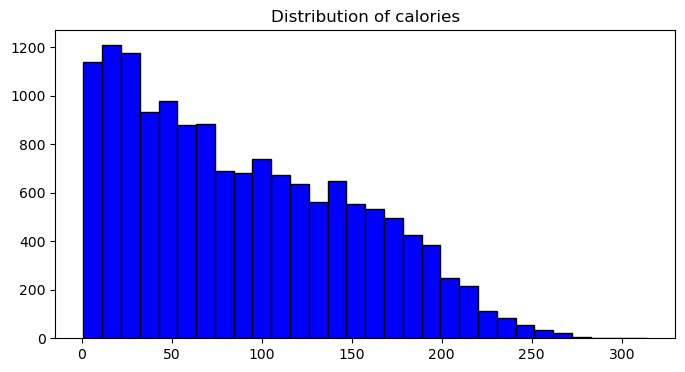

In [8]:
plt.figure(figsize=(8,4))
plt.hist(df['Calories'],bins=30, color='blue',edgecolor='black')
plt.title('Distribution of calories')
plt.show()

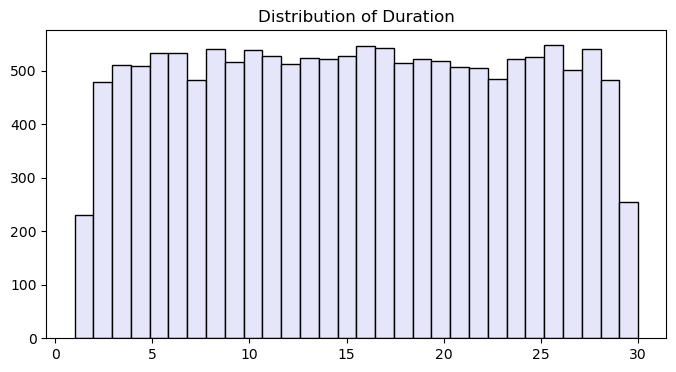

In [9]:
plt.figure(figsize=(8,4))
plt.hist(df['Duration'],bins=30, color='lavender',edgecolor='black')
plt.title('Distribution of Duration')
plt.show()

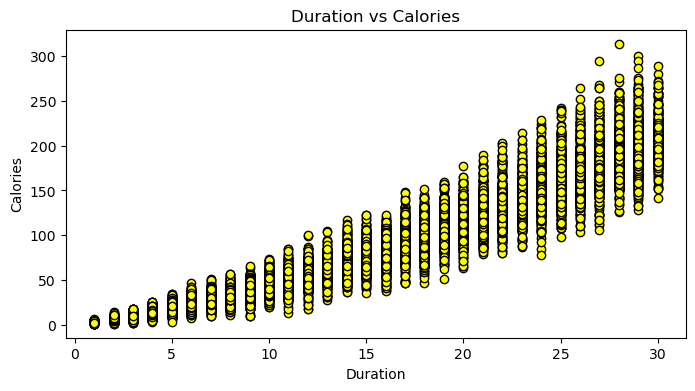

In [10]:
plt.figure(figsize=(8,4))
plt.scatter(df['Duration'],df['Calories'],color='yellow', edgecolor='black')
plt.title('Duration vs Calories')
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.show()

In [11]:
df_corr=df.copy()
df_corr=df_corr.drop(columns=['User_ID','Gender'])

In [12]:
df_corr.columns

Index(['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories'],
      dtype='object')

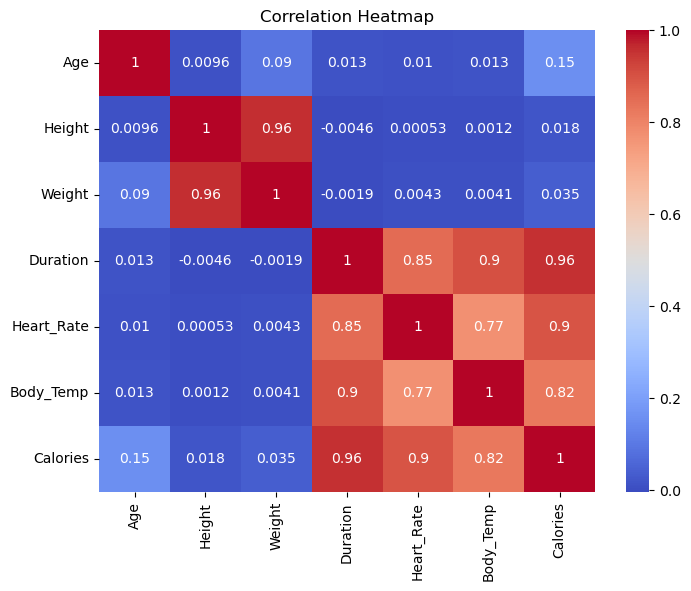

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
df_clean=df.copy()
df_clean.drop(columns=['User_ID'], inplace=True)

In [15]:
print(df_clean.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')


In [16]:
le=LabelEncoder()
df_clean['Gender']=le.fit_transform(df_clean['Gender'])
print(df_clean['Gender'].unique())

[1 0]


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [18]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [19]:
Q1=df_clean['Weight'].quantile(0.25)
Q3=df_clean['Weight'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print('Q1:',Q1)
print('Q3:',Q3)
print('IQR:',IQR)
print('Lower:',lower)
print('Upper:',upper)

Q1: 63.0
Q3: 87.0
IQR: 24.0
Lower: 27.0
Upper: 123.0


In [20]:
df_clean=df_clean[(df_clean['Weight']>=lower) & (df_clean['Weight']<=upper)]

In [21]:
print(df_clean.shape)

(14994, 8)


In [22]:
Q1=df_clean['Height'].quantile(0.25)
Q3=df_clean['Height'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print(Q1)
print(Q3)
print(IQR)
print(lower)
print(upper)

164.0
185.0
21.0
132.5
216.5


In [23]:
df_clean=df_clean[(df_clean['Height']>=132) & (df_clean['Height']<=216)]

In [24]:
print('Height:',df_clean.shape)

Height: (14989, 8)


In [25]:
Q1=df_clean['Calories'].quantile(0.25)
Q3=df_clean['Calories'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print('Q1:',Q1)
print('Q3:',Q3)
print('IQR:',IQR)
print('Lower:',lower)
print('Upper:',upper)

Q1: 35.0
Q3: 138.0
IQR: 103.0
Lower: -119.5
Upper: 292.5


In [26]:
df_clean=df_clean[(df_clean['Calories']>=lower) & (df_clean['Calories']<=upper)]

In [27]:
print('Calories:',df_clean.shape)

Calories: (14985, 8)


In [28]:
Q1=df_clean['Body_Temp'].quantile(0.25)
Q3=df_clean['Body_Temp'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print('Q1:',Q1)
print('Q3:',Q3)
print('IQR:',IQR)
print('Lower:',lower)
print('Upper:',upper)

Q1: 39.6
Q3: 40.6
IQR: 1.0
Lower: 38.1
Upper: 42.1


In [29]:
df_clean=df_clean[(df_clean['Body_Temp']>=38.1) & (df_clean['Body_Temp']<=upper)]

In [30]:
print('Body_Temp:',df_clean.shape)

Body_Temp: (14617, 8)


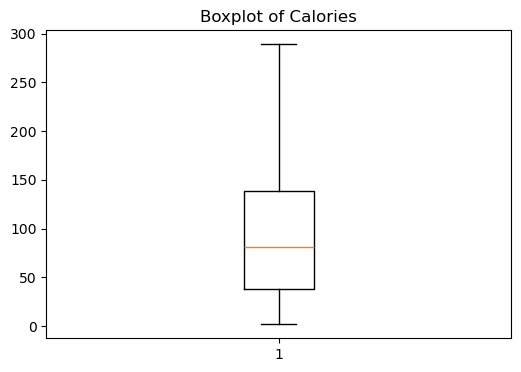

In [31]:
# Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df_clean['Calories'])
plt.title('Boxplot of Calories')
plt.show()

In [32]:
# creating BMI column
df_clean['BMI']=df_clean['Weight']/(df_clean['Height']/100)**2

In [33]:
df_clean['BMI'].head()

0    26.038781
1    21.773842
2    24.655910
3    22.159109
4    24.456063
Name: BMI, dtype: float64

In [34]:
df_clean['Exercise_Intensity']=df_clean['Duration'] * df_clean['Heart_Rate']

In [35]:
df_clean['Exercise_Intensity'].head()

0    3045.0
1    1316.0
2     440.0
3    1300.0
4     810.0
Name: Exercise_Intensity, dtype: float64

In [36]:
df_clean.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Exercise_Intensity
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,3045.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,1316.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,440.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109,1300.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063,810.0


In [52]:
df_clean.drop(columns=['Exercise Intensity'], inplace=True)
print(df_clean.columns)

KeyError: "['Exercise Intensity'] not found in axis"

In [37]:
df_clean.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Exercise_Intensity
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,3045.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,1316.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,440.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109,1300.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063,810.0


In [38]:
# Model Building

In [39]:
X=df_clean.drop(columns=['Calories'])
y=df_clean['Calories']

In [40]:
print(X.shape)
print(y.shape)

(14617, 9)
(14617,)


In [41]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
print(X_train.shape)
print(X_test.shape)

(11693, 9)
(2924, 9)


In [43]:
# Linear Regreesion

In [44]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [45]:
# Metrics Evaluation using MSE,RMSE,MAE,R2

In [46]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2 Score:',r2)

MAE: 5.746132695049343
MSE: 60.55153744102929
RMSE: 7.781486839995894
R2 Score: 0.9845863182623246


In [47]:
# Decision Tree

In [48]:
dt=DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

In [49]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2 Score:',r2)

MAE: 3.825879136205627
MSE: 31.33844150379559
RMSE: 5.5980748033404835
R2 Score: 0.9920226507218798


In [50]:
# Random Forest

In [51]:
rf=RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

In [52]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2 Score:',r2)

MAE: 1.7994938440492474
MSE: 8.097795759233925
RMSE: 2.845662622173248
R2 Score: 0.9979386675898843


In [53]:
# SVM (Support Vector Regression)

In [54]:
svr=Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf',C=100,epsilon=0.1))
])
svr.fit(X_train,y_train)
y_pred=svr.predict(X_test)

In [55]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2 Score:',r2)

MAE: 0.31830691143792317
MSE: 0.2648095307309434
RMSE: 0.5145964736868524
R2 Score: 0.9999325914749603


In [56]:
pickle.dump(svr, open('model.pkl', 'wb'))
print('model saved!')

model saved!
